In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


[0.00000e+00 1.00000e+00 1.36955e-32]


Text(0.02, 0.5, '$ACF$')

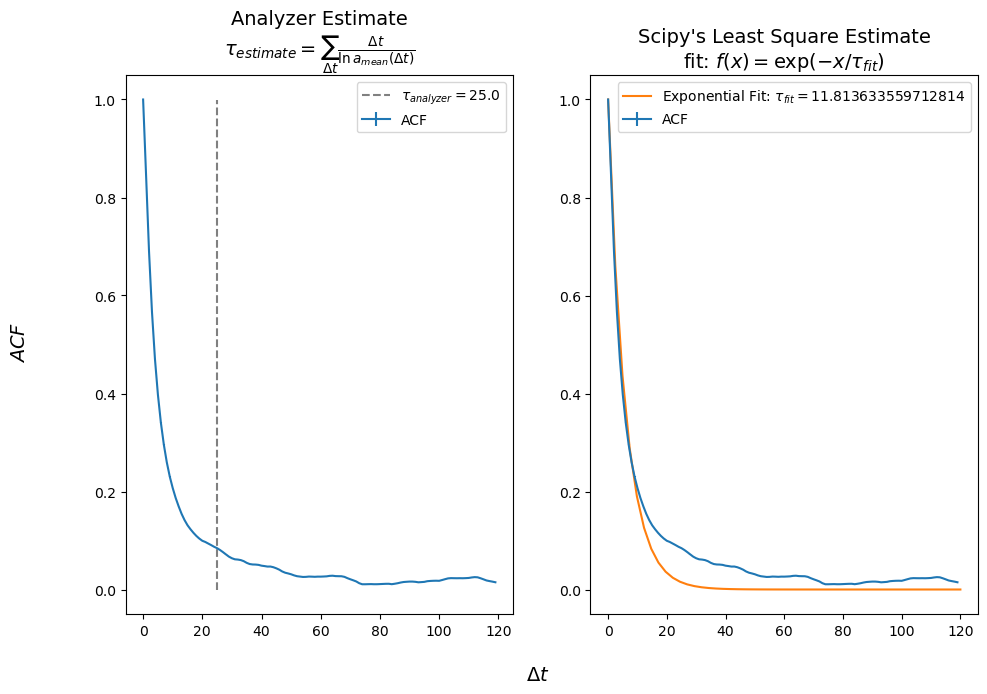

In [34]:
figsize = (11,7)

KPKL = "NoVectorField"
directory = f"/lustre/astro/semygind/Analyzer/version_1/{KPKL}/AutoCorrelationFunction/"
#directory = f"/lustre/astro/semygind/Analyzer/version_1/DirectFourierData/"
i = 5

values = np.genfromtxt(directory+f'q{i}.txt',
                       skip_header=3)

q, tau = np.genfromtxt(directory+f'q{i}.txt',
                       skip_header=1,max_rows=1)


i1 = 0
i2 = int(tau)*5

def exponential(X,TAU):
    return np.exp(-2*X/TAU)


par, cov = curve_fit(exponential,values[i1:i2,0],values[i1:i2,1],sigma=np.sqrt(values[i1:i2,2]))
print(values[0])
X = np.linspace(i1,i2)
Y = exponential(X,*par)

fig , ax = plt.subplots(1,2,figsize=figsize)
ax[0].errorbar(values[i1:i2,0],values[i1:i2,1],yerr=np.sqrt(values[i1:i2,2])/(len(values[i1:i2,0]-1)),label="ACF")
ax[0].vlines(tau,0,1,linestyles='dashed',colors='gray',label=rf"$\tau_{{analyzer}} = {np.round(tau,0)}$")
ax[0].legend()
ax[0].set_title("Analyzer Estimate\n"+fr"$\tau_{{estimate}}=\sum_{{\Delta t}} {{\frac{{\Delta t}}{{\ln{{a_{{mean}}(\Delta t)}}}}}}$",fontsize=14)

ax[1].errorbar(values[i1:i2,0],values[i1:i2,1],yerr=np.sqrt(values[i1:i2,2])/(len(values[i1:i2,0]-1)),label="ACF")
ax[1].plot(X,Y,label=rf"Exponential Fit: $\tau_{{fit}} ={par[0]}$")
ax[1].legend()
ax[1].set_title("Scipy's Least Square Estimate\n"+rf"fit: $f(x)=\exp(-x/\tau_{{fit}})$",fontsize=14)


fig.supxlabel(rf"$\Delta t$",fontsize=14)
fig.supylabel(rf"$ACF$",fontsize=14)

1.0


Text(0.02, 0.5, '$ACF$')

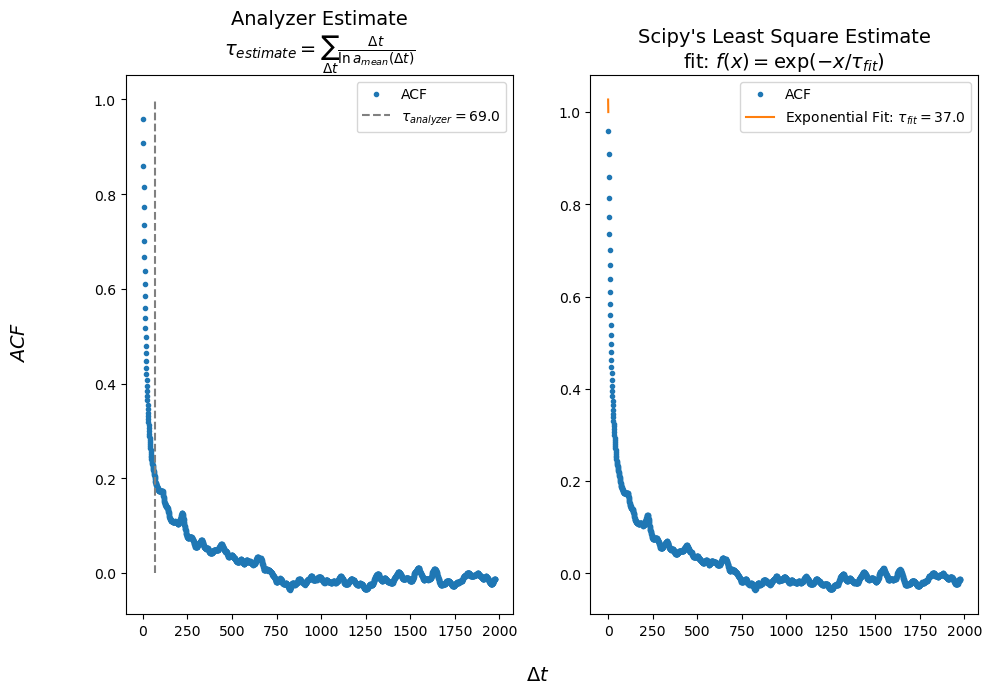

In [14]:

figsize = (11,7)
Test= "NormalACC_ComplexAmean"
directory = f"/lustre/astro/semygind/Analyzer/version_1/test/{Test}/AutoCorrelationFunction/"

i = 0
i1 = 0

i2 = -1

values = np.genfromtxt(directory+f'q{i}.txt',
                    skip_header=4)

q, tau = np.genfromtxt(directory+f'q{i}.txt',
                       skip_header=1,max_rows=1)

def exponential(X,TAU):
    return np.exp(-X/TAU)

par, cov = curve_fit(exponential,values[i1:i2,0],values[i1:i2,1])
X = np.linspace(0,i2)
Y = exponential(X,*par)

fig , ax = plt.subplots(1,2,figsize=figsize)
ax[0].plot(values[i1:i2,0],values[i1:i2,1],'.',label="ACF")
ax[0].vlines(tau,0,1,linestyles='dashed',colors='gray',label=rf"$\tau_{{analyzer}} = {np.round(tau,0)}$")
ax[0].legend()
ax[0].set_title("Analyzer Estimate\n"+fr"$\tau_{{estimate}}=\sum_{{\Delta t}} {{\frac{{\Delta t}}{{\ln{{a_{{mean}}(\Delta t)}}}}}}$",fontsize=14)

ax[1].plot(values[i1:i2,0],values[i1:i2,1],'.',label="ACF")
ax[1].plot(X,Y,label=rf"Exponential Fit: $\tau_{{fit}} ={np.round(par[0],0)}$")
ax[1].legend()
ax[1].set_title("Scipy's Least Square Estimate\n"+rf"fit: $f(x)=\exp(-x/\tau_{{fit}})$",fontsize=14)

print(values[i1,0])


fig.supxlabel(rf"$\Delta t$",fontsize=14)
fig.supylabel(rf"$ACF$",fontsize=14)